<a href="https://colab.research.google.com/github/the-star-boy/Local-repo/blob/main/Random_sample_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df= pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [47]:
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [48]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [49]:
x= df.drop(columns=['Survived'])
y= df['Survived']

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [51]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']


In [52]:
x_train.head()


,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0


In [53]:
# For x_train
null_mask_train = x_train['Age_imputed'].isnull()
num_nulls_train = null_mask_train.sum()
if num_nulls_train > 0:
    non_null_ages_train = x_train['Age'].dropna().values
    sampled_values_train = np.random.choice(non_null_ages_train, size=num_nulls_train, replace=True)
    x_train.loc[null_mask_train, 'Age_imputed'] = sampled_values_train

# For x_test, sample from x_train's non-null ages
null_mask_test = x_test['Age_imputed'].isnull()
num_nulls_test = null_mask_test.sum()
if num_nulls_test > 0:
    non_null_ages_from_x_train = x_train['Age'].dropna().values
    sampled_values_test = np.random.choice(non_null_ages_from_x_train, size=num_nulls_test, replace=True)
    x_test.loc[null_mask_test, 'Age_imputed'] = sampled_values_test

In [54]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum(), replace=True).values

array([ 0.75, 26.  , 33.  , 31.  , 34.5 , 27.  , 26.  , 14.  , 32.  ,
       45.  ,  4.  , 17.  , 14.  , 27.  , 30.  , 19.  , 19.  , 27.  ,
       24.  , 21.  , 27.  , 30.  , 28.  , 28.  , 31.  , 50.  , 30.  ,
       24.  , 17.  , 25.  , 26.  , 18.  , 16.  , 30.  , 36.  , 22.  ,
       47.  , 19.  , 22.  , 19.  , 27.  , 24.  , 17.  , 51.  , 35.  ,
       24.  , 28.  , 26.  , 30.  , 31.  , 17.  ,  0.83, 44.  , 19.  ,
       18.  , 43.  , 42.  , 26.  , 54.  , 17.  , 24.5 ,  1.  , 18.  ,
        4.  , 17.  , 58.  , 32.  , 17.  , 15.  , 24.  , 48.  , 36.  ,
        1.  , 21.  , 33.  , 46.  , 17.  , 22.  , 31.  , 30.  , 30.  ,
       24.  , 44.  , 25.  , 24.5 , 41.  , 22.  , 26.  , 44.  , 24.  ,
       43.  , 24.  , 33.  , 46.  , 27.  , 22.  , 25.  , 21.  , 58.  ,
       19.  , 10.  , 28.  , 28.  , 39.  ,  0.42, 36.  ,  8.  , 19.  ,
       60.  , 45.  ,  8.  , 29.  , 21.  , 31.  , 23.  , 40.  , 32.  ,
       22.  , 40.  , 28.  , 45.5 ,  2.  , 40.  , 10.  , 28.  , 25.  ,
        3.  , 35.  ,

In [55]:
x_train['Age'].isnull().sum()

np.int64(140)

In [56]:
x_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,19.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


/tmp/ipykernel_2834/3216122529.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'], hist=False, color='blue', label='Original')
/tmp/ipykernel_2834/3216122529.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age_imputed'], hist=False, color='red', lab

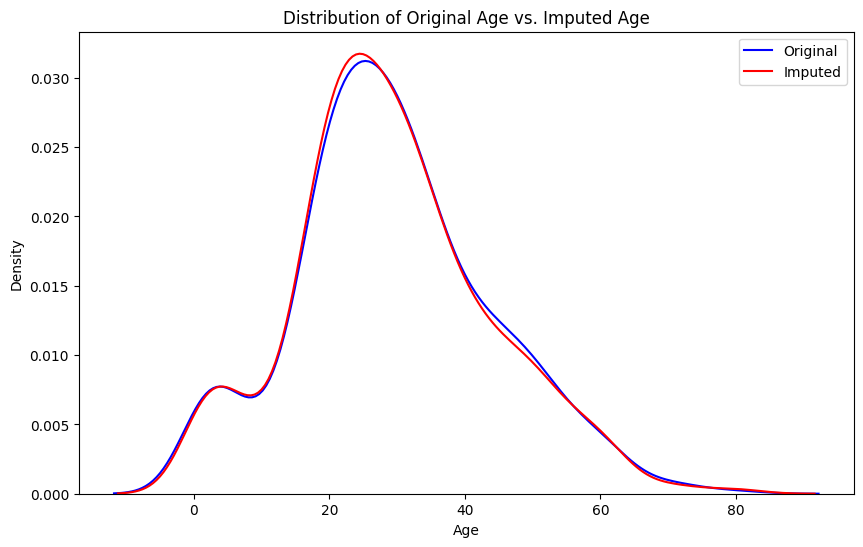

In [57]:
plt.figure(figsize=(10, 6))
sns.distplot(x_train['Age'], hist=False, color='blue', label='Original')
sns.distplot(x_train['Age_imputed'], hist=False, color='red', label='Imputed')
plt.title('Distribution of Original Age vs. Imputed Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [58]:
print('Original variable var',x_train['Age'].var())
print('Imputed variable var',x_train['Age_imputed'].var())

Original variable var 210.2517072477438
Imputed variable var 208.05905556958032


<Axes: >

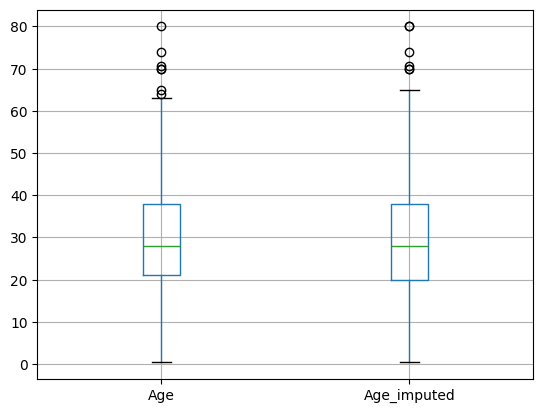

In [59]:
x_train[['Age','Age_imputed']].boxplot()